In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.metrics import classification_report
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
#1 load dataset
data = pd.read_csv("/content/diabetes (1).csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
#2 Seperate features and target
X = data.drop('Outcome', axis=1) # features
y = data['Outcome'] # target(0= no diabetes,,1= diabetic)


In [7]:
#3 train & test
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

#4 model fit
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
# 5 evaluate a  model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
classification_rep = classification_report(y_test, y_pred)
print("Classification Report:\n", classification_rep)
confusion_mat = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", confusion_mat)


Accuracy: 0.7532467532467533
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.78      0.80        99
           1       0.64      0.71      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.74       154
weighted avg       0.76      0.75      0.76       154

Confusion Matrix:
 [[77 22]
 [16 39]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


The patient is diabetic.


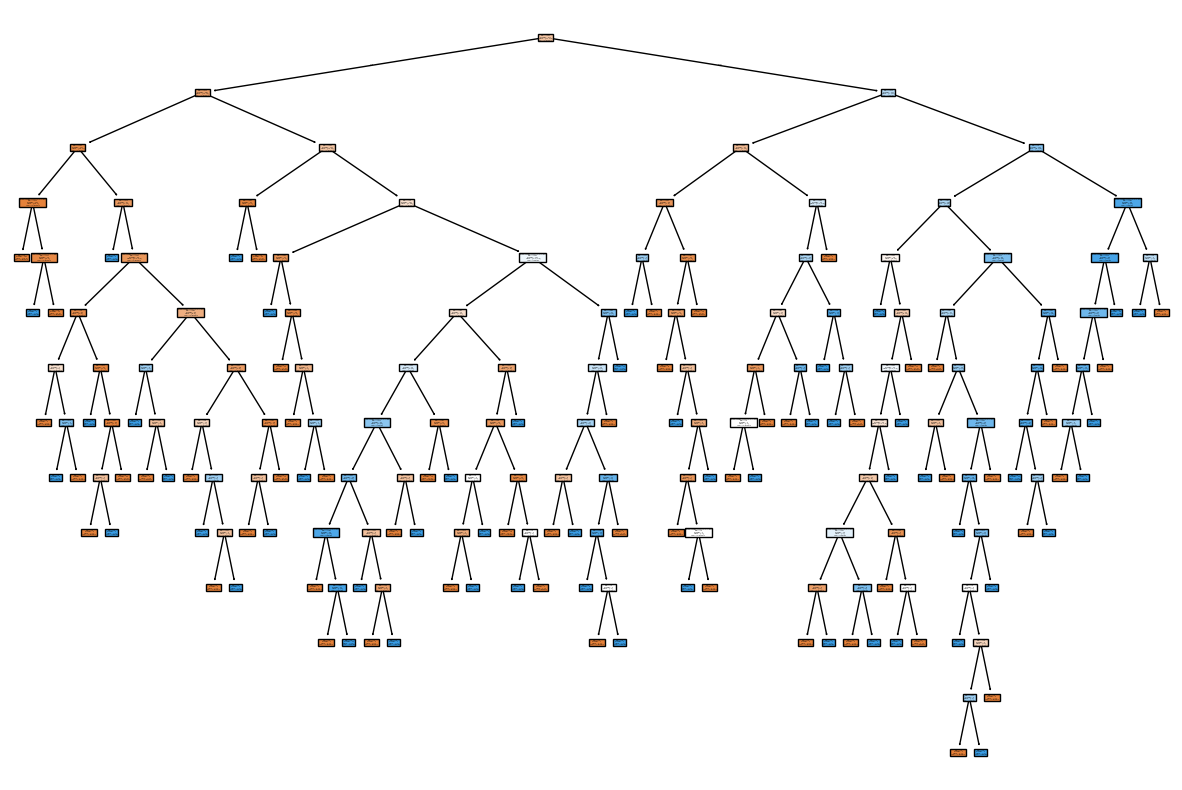

In [9]:
# predict about a new patient
new_patient = [[6,148,72,35,0,33.6,35,67]]
prediction = model.predict(new_patient)
if prediction[0] == 0:
    print("The patient is not diabetic.")
else:
    print("The patient is diabetic.")

plt.figure(figsize=(15,10))
plot_tree(model, filled=True, feature_names=X.columns, class_names=['No Diabetes', 'Diabetes'])
plt.show()